In [4]:
import uuid
import operator
from core.logger import app_logger
from typing import TypedDict, Annotated, Any
from langgraph.graph import StateGraph, START, END
from langgraph.constants import Send

from models.schemas import (EducationalMetadata, 
                            ExtractedKnowledge, 
                            TeachingPlan,
                            PeriodContent,
                            LearningGapAnalysis)
from pipelines.phase1_extraction.extractor import knowledge_extractor
from pipelines.phase2_generation.planner import teaching_planner
from pipelines.phase2_generation.content_gen import content_generator
from pipelines.phase2_generation.learning_gap import learning_gap_analyzer

from pipelines.phase1_extraction.chunker import document_chunker
from infrastructure.vector_store import vector_store

from core.exceptions import (ExtractionError, 
                            TeachingPlanError)
from langgraph.checkpoint.postgres import PostgresSaver


class PipelineState(TypedDict):
    job_id : str
    raw_text: str
    metadata: EducationalMetadata | None
    knowledge_base: ExtractedKnowledge | None
    teaching_plan: TeachingPlan | None
    learning_gaps: LearningGapAnalysis | None
    
    period_contents: Annotated[list[PeriodContent], operator.add]
    
    validation_errors: list[str]
    current_stage: str

class PeriodState(TypedDict):
    job_id: str
    period: Any
    metadata: EducationalMetadata | None


def educational_classification_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    app_logger.info("Starting Educational Classification", extra={"extra_info": {"job_id": job_id, "stage": 2}})
    try:
        result: EducationalMetadata = knowledge_extractor.extract_metadata(
            raw_markdown=state["raw_text"], job_id=job_id
        )
        return {"metadata": result, "current_stage": "Stage 2 Complete"}
    except Exception as e:
        app_logger.error(f"Classification failed: {str(e)}", extra={"extra_info": {"job_id": job_id}})
        raise ExtractionError(message="Stage 2 Failed", details={"job_id": job_id})

def knowledge_extraction_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    app_logger.info("Starting Knowledge Extraction", extra={"extra_info": {"job_id": job_id, "stage": 3}})
    try:
        result: ExtractedKnowledge = knowledge_extractor.extract_knowledge(
            metadata_json=state["metadata"], raw_markdown=state["raw_text"], job_id=job_id
        )
        return {"knowledge_base": result, "current_stage": "Stage 3 Complete"}
    except Exception as e:
        app_logger.error(f"Extraction failed: {str(e)}", extra={"extra_info": {"job_id": job_id}})
        raise ExtractionError(message="Stage 3 Failed", details={"job_id": job_id})

def vectorization_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    app_logger.info("Starting Document Vectorization", extra={"extra_info": {"job_id": job_id, "stage": 3.5}})
    try:
        chunks = document_chunker.chunk_markdown(state["raw_text"])
        vector_store.ingest_chunks(job_id=job_id, chunks=chunks)
        return {"current_stage": "Stage 3.5 Complete"}
    except Exception as e:
        app_logger.error(f"Vectorization failed: {str(e)}", extra={"extra_info": {"job_id": job_id}})
        raise ExtractionError(message="Stage 3.5 Failed", details={"job_id": job_id})

def teaching_planner_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    app_logger.info("Starting Teaching Planning", extra={"extra_info": {"job_id": job_id, "stage": 4}})
    try:
        result: TeachingPlan = teaching_planner.planner(
            metadata_json=state["metadata"], extracted_knowledge=state["knowledge_base"], job_id=job_id
        )
        return {"teaching_plan": result, "current_stage": "Stage 4 Complete"}
    except Exception as e:
        app_logger.error(f"Planning failed: {str(e)}", extra={"extra_info": {"job_id": job_id}})
        raise TeachingPlanError(message="Stage 4 Failed", details={"job_id": job_id})

def generate_period_content_node(state: PeriodState) -> dict:
    job_id = state["job_id"]
    app_logger.info(f"Fan-out worker running for Period {state['period'].period_number}")
    result: PeriodContent = content_generator.generate_single_period(metadata=state["metadata"], job_id=job_id, period=state["period"])
    return {"period_contents": [result]}


def fan_out_periods(state: PipelineState):
    plan = state.get("teaching_plan")
    if not plan or not plan.periods:
        app_logger.warning("No periods found in plan, exiting workflow.")
        return END
        
    app_logger.info(f"Fanning out into {len(plan.periods)} parallel generation threads...")
    
    return [
        Send("generate_period_content", {
            "job_id": state["job_id"],
            "period": p,
            "metadata": state["metadata"]
        }) for p in plan.periods
    ]

def analyze_learning_gaps_node(state: PipelineState) -> dict:
    job_id = state["job_id"]
    app_logger.info("Starting Learning Gap Analysis", extra={"extra_info": {"job_id": job_id, "stage": 8}})
    
    try:
        result = learning_gap_analyzer.learning_gap_node(
            metadata_json=state["metadata"],
            job_id=job_id, 
            knowledge_base=state["knowledge_base"]
        )
        return {"learning_gaps": result, "current_stage": "Stage 8 Complete"}
    except Exception as e:
        app_logger.error(f"Gap Analysis failed: {str(e)}", extra={"extra_info": {"job_id": job_id}})
        raise LLMGenerationError(message="Stage 8 Failed", details={"job_id": job_id})
    
    
workflow = StateGraph(PipelineState)

# Add Nodes
workflow.add_node("classify", educational_classification_node)
workflow.add_node("extract", knowledge_extraction_node)
workflow.add_node("vectorize", vectorization_node)
workflow.add_node("plan", teaching_planner_node)
workflow.add_node("analyze_gaps", analyze_learning_gaps_node) 
workflow.add_node("generate_period_content", generate_period_content_node)

# Sequential Core Flow
workflow.add_edge(START, "classify")
workflow.add_edge("classify", "extract")
workflow.add_edge("extract", "vectorize")
workflow.add_edge("vectorize", "plan")
workflow.add_edge("plan", "analyze_gaps") 

# Dynamic Map-Reduce Fan-Out (Now triggers after gaps are analyzed)
workflow.add_conditional_edges("analyze_gaps", fan_out_periods, ["generate_period_content"])

# Fan-In to END
workflow.add_edge("generate_period_content", END)


C:\Users\priya\AppData\Local\Temp\ipykernel_10588\2749178299.py:6: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


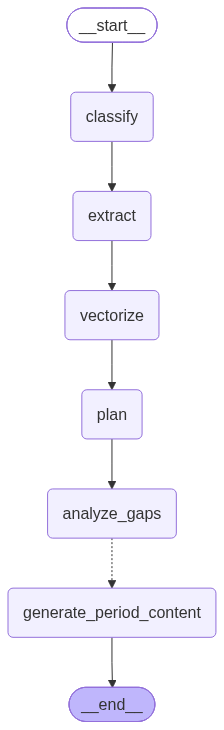

In [5]:
workflow.compile()